# Machine Learning — Bike Sharing

Este notebook apresenta a etapa de modelagem preditiva dos dados de aluguel de bicicletas, com o objetivo de desenvolver modelos capazes de prever a demanda por aluguéis nas próximas 24 horas.

A partir dos padrões identificados na análise exploratória, serão utilizadas variáveis temporais, climáticas e informações sobre o comportamento recente da demanda. Também serão avaliadas diferentes abordagens de modelagem e métricas de desempenho, buscando identificar quais modelos apresentam melhores resultados para o problema de previsão.

In [1]:
import pandas as pd

DATA_PATH = '../data/'
file_name = 'bike_sharing_silver.csv'

df = pd.read_csv(DATA_PATH+file_name, sep=',')
df_eda = df.copy()

df.head()

,instant,season,year,month,hour,holiday,weekday,working_day,weather_sit,temp,feeling_temp,hum,wind_speed,casual,registered,datetime,cnt
0,1,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,2011-01-01 00:00:00,16
1,2,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,2011-01-01 01:00:00,40
2,3,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,2011-01-01 02:00:00,32
3,4,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,2011-01-01 03:00:00,13
4,5,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,2011-01-01 04:00:00,1


In [2]:
TARGET_COLUMN = 'cnt'
NUMERIC_COLUMNS = ['temp', 'feeling_temp', 'hum', 'wind_speed', 'casual', 'registered']
CATEGORICAL_COLUMNS = ['holiday', 'weekday', 'working_day', 'weather_sit']
DATETIME_COLUMN = 'datetime'

# Rolling Features

As rolling features permitem resumir o comportamento recente da demanda em diferentes janelas de tempo. A média e a mediana representam o nível central da demanda, enquanto o desvio-padrão representa sua variabilidade. Já os valores mínimo e máximo indicam os extremos observados dentro da janela.

Foram criadas as rolling features de média, mediana, desvio-padrão, mínimo e máximo para as janelas de 6, 24 e 168 horas. A janela de 6 horas representa o comportamento mais recente, enquanto as janelas de 24 e 168 horas permitem capturar comportamentos relacionados aos padrões diário e semanal identificados na análise da série.

Para evitar vazamento de informação, as estatísticas foram calculadas utilizando somente valores anteriores ao instante que será previsto, sem incluir informações futuras.

In [3]:
windows = [6, 24, 168]

for window in windows:
    mean_column = 'rolling_mean_' + str(window)
    median_column = 'rolling_median_' + str(window)
    std_column = 'rolling_std_' + str(window)
    min_column = 'rolling_min_' + str(window)
    max_column = 'rolling_max_' + str(window)
    
    df[mean_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).mean()
    
    df[median_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).median()
    
    df[std_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).std()
    
    df[min_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).min()
    
    df[max_column] = df[TARGET_COLUMN].shift(1).rolling(window=window).max()

df.shape

(17379, 32)

### Lags

As variáveis de lag permitem utilizar valores anteriores da demanda como informações para a previsão, incorporando ao modelo a dependência temporal existente na série. Diferentemente das rolling features, que resumem um conjunto de observações, cada lag representa o valor da demanda em um ponto específico do passado.

Foram criadas as variáveis `lag_1`, `lag_6`, `lag_24` e `lag_168`. O `lag_1` representa a demanda da hora anterior, enquanto o `lag_6` representa a demanda observada seis horas antes. Já os `lag_24` e `lag_168` permitem utilizar, respectivamente, a demanda do mesmo horário do dia anterior e da semana anterior, considerando os padrões diário e semanal identificados na análise da série.

A criação desses lags foi baseada nos padrões de autocorrelação observados durante a análise exploratória, especialmente nas defasagens relacionadas ao comportamento diário e semanal. Dessa forma, essas variáveis permitem que o modelo utilize informações recentes e padrões recorrentes da demanda para realizar as previsões.

In [4]:
for lag in [1, 6, 24, 168]:
    df[f'lag_{lag}'] = df[TARGET_COLUMN].shift(lag)

In [5]:
df.shape

(17379, 36)

## Seleção das variáveis

Antes do treinamento dos modelos, foram removidas as colunas `casual`, `registered`, `temp`, `datetime` e `weekday` do conjunto de dados utilizado no treinamento.

A remoção foi realizada com base nos motivos identificados durante a análise exploratória, considerando redundância entre variáveis, risco de vazamento de informação, características temporais já representadas por outras variáveis e informações que não serão utilizadas diretamente pelo modelo.


In [6]:
df_ml = df.drop(columns=['casual', 'registered', 'temp', 'datetime', 'weekday']).iloc[168:]
df_ml

,instant,season,year,month,hour,holiday,working_day,weather_sit,feeling_temp,hum,...,rolling_max_24,rolling_mean_168,rolling_median_168,rolling_std_168,rolling_min_168,rolling_max_168,lag_1,lag_6,lag_24,lag_168
168,169,1,0,1,7,0,0,2,0.1818,0.74,...,210.0,56.458333,49.0,51.220768,1.0,219.0,2.0,16.0,84.0,16.0
169,170,1,0,1,8,0,0,3,0.1818,0.93,...,210.0,56.416667,49.0,51.256712,1.0,219.0,9.0,16.0,210.0,40.0
170,171,1,0,1,9,0,0,3,0.1818,0.93,...,187.0,56.267857,49.0,51.340879,1.0,219.0,15.0,7.0,134.0,32.0
171,172,1,0,1,10,0,0,2,0.1970,0.80,...,187.0,56.196429,49.0,51.383175,1.0,219.0,20.0,1.0,63.0,13.0
172,173,1,0,1,11,0,0,2,0.1818,0.69,...,187.0,56.482143,50.5,51.274881,1.0,219.0,61.0,5.0,67.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,1,1,12,19,0,1,2,0.2576,0.60,...,315.0,72.815476,43.0,73.152342,1.0,315.0,122.0,203.0,102.0,26.0
17375,17376,1,1,12,20,0,1,2,0.2576,0.60,...,315.0,73.369048,43.5,73.147833,1.0,315.0,119.0,247.0,72.0,18.0
17376,17377,1,1,12,21,0,1,1,0.2576,0.60,...,315.0,73.791667,44.0,73.031029,1.0,315.0,89.0,315.0,47.0,23.0
17377,17378,1,1,12,22,0,1,1,0.2727,0.56,...,315.0,74.190476,44.5,72.934878,1.0,315.0,90.0,214.0,36.0,22.0


# Separação dos dados de treino e teste

Os dados foram separados respeitando a ordem cronológica das observações. Em séries temporais, não é adequado realizar uma divisão aleatória entre treino e teste, pois isso poderia fazer com que o modelo fosse treinado com informações de períodos posteriores ao período utilizado para avaliação.

Para evitar esse problema, foi utilizado o `TimeSeriesSplit`, que realiza divisões sequenciais dos dados. Em cada divisão, o modelo é treinado utilizando apenas as observações anteriores e avaliado em um período posterior.

Essa abordagem simula melhor o cenário real de previsão, no qual utilizamos dados históricos para prever valores futuros, além de permitir avaliar a consistência do modelo em diferentes períodos da série.


In [7]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=24)

X = df_ml.drop(columns=[TARGET_COLUMN])
y = df_ml[TARGET_COLUMN]

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

## Métricas de avaliação

* MAE (Mean Absolute Error): representa o erro absoluto médio entre os valores reais e os valores previstos. Quanto menor o MAE, menor é o erro médio das previsões.

* RMSE (Root Mean Squared Error): calcula a raiz do erro quadrático médio. Como ele dá maior peso aos erros maiores, valores elevados indicam a presença de previsões com erros mais acentuados. Quanto menor o RMSE, melhor o desempenho.

* MAPE (Mean Absolute Percentage Error): representa o erro absoluto médio em termos percentuais. Facilita a interpretação do erro em relação ao valor real. Quanto menor o MAPE, menor é o erro percentual médio.

* R² (Coeficiente de Determinação): indica a proporção da variação da variável alvo que é explicada pelo modelo. Seu valor pode variar de menos infinito a 1, sendo que valores mais próximos de 1 indicam maior capacidade de explicar a variação observada.


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

SEED = 42

def fit_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

    return metrics


models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=SEED),
    'Random Forest': RandomForestRegressor(random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(random_state=SEED),
    'XGBoost': XGBRegressor(random_state=SEED)
}

results = []


for model_name, model in models.items():
    fold_metrics = []

    metrics = fit_model(model, X_train, y_train, X_test, y_test)
    fold_metrics.append(metrics)
    
    average_metrics = pd.DataFrame(fold_metrics).mean().to_dict()
    average_metrics['Model'] = model_name
    
    results.append(average_metrics)

metrics_df = pd.DataFrame(results)


# Comparação dos modelos

O Random Forest apresentou o melhor desempenho entre os modelos avaliados. Ele obteve o menor MAE (14,24), o menor RMSE (20,17) e o menor MAPE (0,2695), indicando menores erros nas previsões. Além disso, apresentou o maior R² (0,9065), indicando que o modelo conseguiu explicar uma maior proporção da variação observada na demanda.

Em comparação, os demais modelos apresentaram valores de erro superiores e R² inferior. Dessa forma, com base nas métricas utilizadas nesta etapa de validação, o Random Forest apresentou o melhor desempenho preditivo entre os modelos avaliados.

In [11]:
metrics_df

,MAE,RMSE,MAPE,R2,Model
0,35.137945,52.041645,1.211270,0.634538,Linear Regression
1,21.583333,29.429294,0.443495,0.883131,Decision Tree
2,20.320833,30.931850,0.350707,0.870892,Random Forest
3,25.375652,37.287136,0.519536,0.812389,Gradient Boosting
4,30.611185,44.262673,0.576980,0.735628,XGBoost


# Análise dos folds

Foram analisados os resultados de cada fold do Random Forest para verificar a consistência do desempenho ao longo dos diferentes períodos de validação e identificar possíveis sinais de overfitting.

As métricas apresentaram alguma variação entre os folds, principalmente no último, que apresentou os maiores valores de MAE (20,32), RMSE (30,93) e MAPE (0,3507), além do menor R² entre os folds (0,8709). Apesar dessa variação, o modelo manteve R² acima de 0,86 e valores de erro relativamente próximos nos diferentes períodos avaliados.

Dessa forma, os resultados não indicam uma perda acentuada de desempenho entre os folds, sugerindo que o Random Forest apresenta desempenho relativamente consistente ao longo dos períodos de validação.

In [12]:
fold_metrics = []

metrics = fit_model(RandomForestRegressor(random_state=SEED), X_train, y_train, X_test, y_test)
fold_metrics.append(metrics)

df_rf_metric = pd.DataFrame(fold_metrics)
df_rf_metric

,MAE,RMSE,MAPE,R2
0,20.320833,30.93185,0.350707,0.870892


# Ajuste de hiperparâmetros com Grid Search

Foi realizada uma busca de hiperparâmetros utilizando GridSearchCV para avaliar diferentes combinações do Random Forest.

A configuração selecionada apresentou MAE de 19,90, RMSE de 28,41, MAPE de 0,3616 e R² de 0,8911 no conjunto de avaliação.

Com base nos resultados obtidos, essa configuração será utilizada na etapa seguinte do projeto.

In [13]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

param_grid = {
    # A quantidade de parâmetros foi reduzida devido ao tempo de execução
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5]
}

rf = RandomForestRegressor(random_state=SEED)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

cv_results = pd.DataFrame(grid_search.cv_results_)

parameters = [
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]

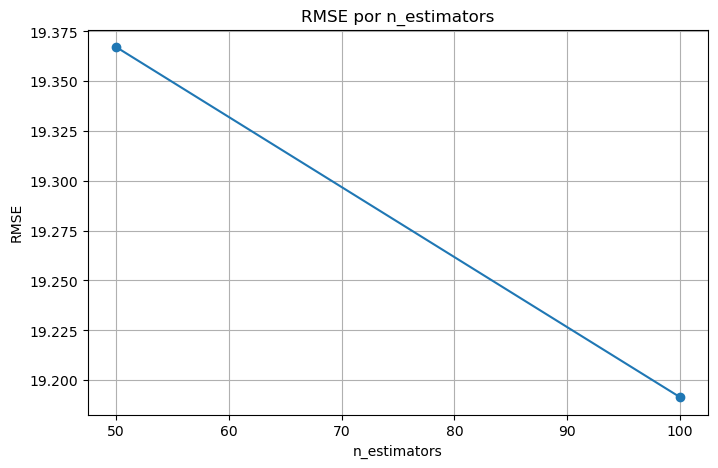

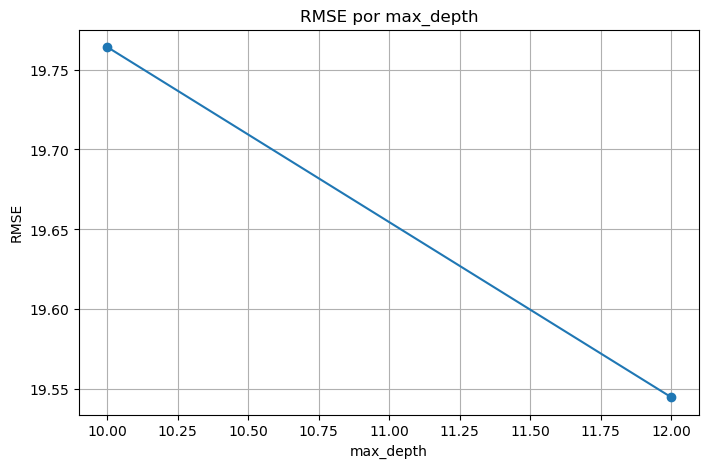

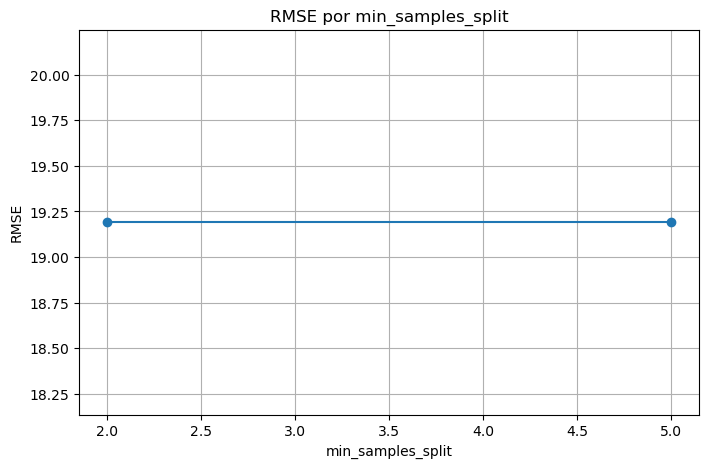

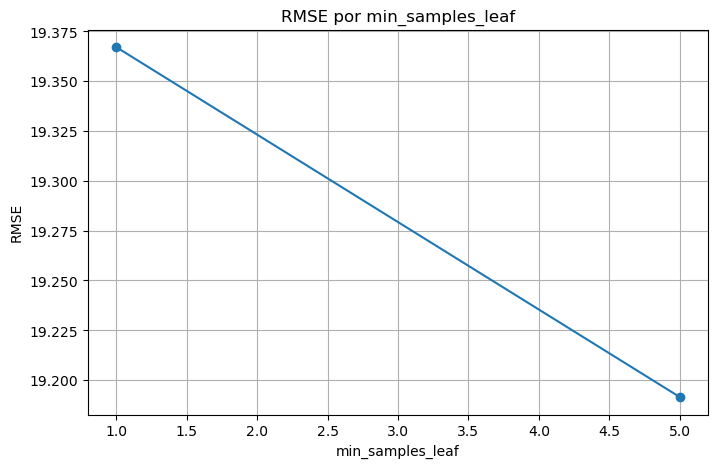

In [14]:
for parameter in parameters:
    grouped_results = cv_results.groupby(parameter)['mean_test_score'].max().reset_index()
    grouped_results['RMSE'] = -grouped_results['mean_test_score']

    plt.figure(figsize=(8, 5))
    plt.plot(grouped_results[parameter], grouped_results['RMSE'], marker='o')
    plt.xlabel(parameter.replace('param_', ''))
    plt.ylabel('RMSE')
    plt.title(f'RMSE por {parameter.replace("param_", "")}')
    plt.grid(True)
    plt.show()

In [15]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'n_estimators': 100}

In [16]:
rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=SEED
)

rf_best.fit(X_train, y_train)

y_pred = rf_best.predict(X_test)

metrics = {
    'MAE': mean_absolute_error(y_test, y_pred),
    'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'MAPE': mean_absolute_percentage_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}

pd.DataFrame([metrics])

,MAE,RMSE,MAPE,R2
0,19.89551,28.409159,0.361643,0.891093
